In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/senarajayawardena/Documents/Dialog/finsight_clean.csv')

for col in ['Customer_Segment', 'Province', 'Urban_Rural']:
    print(f'\n--- By {col} ---')
    print(df.groupby(col)['Savings_Balance']
            .agg(['mean', 'median', 'count'])
            .sort_values('mean', ascending=False)
            .round(0))


--- By Customer_Segment ---
                       mean     median  count
Customer_Segment                             
Premium           2654140.0  2504760.0     91
Regular            425859.0   448867.0    319
Starter             82246.0    85046.0     93
Unknown                 NaN        NaN      0

--- By Province ---
                   mean    median  count
Province                                
Eastern        934620.0  540962.0     50
Sabaragamuwa   879928.0  409667.0     58
Western        837397.0  448582.0    104
North Western  771320.0  510987.0     55
Central        726492.0  448867.0     47
Northern       662592.0  398756.0     59
Southern       656488.0  379254.0     81
Uva            639433.0  420440.0     49

--- By Urban_Rural ---
                 mean    median  count
Urban_Rural                           
Urban        888128.0  510987.0    189
Rural        730859.0  418672.0    125
Suburban     665666.0  368721.0    189


## Q1a - Average Savings Balance by Segment, Province & Urban/Rural

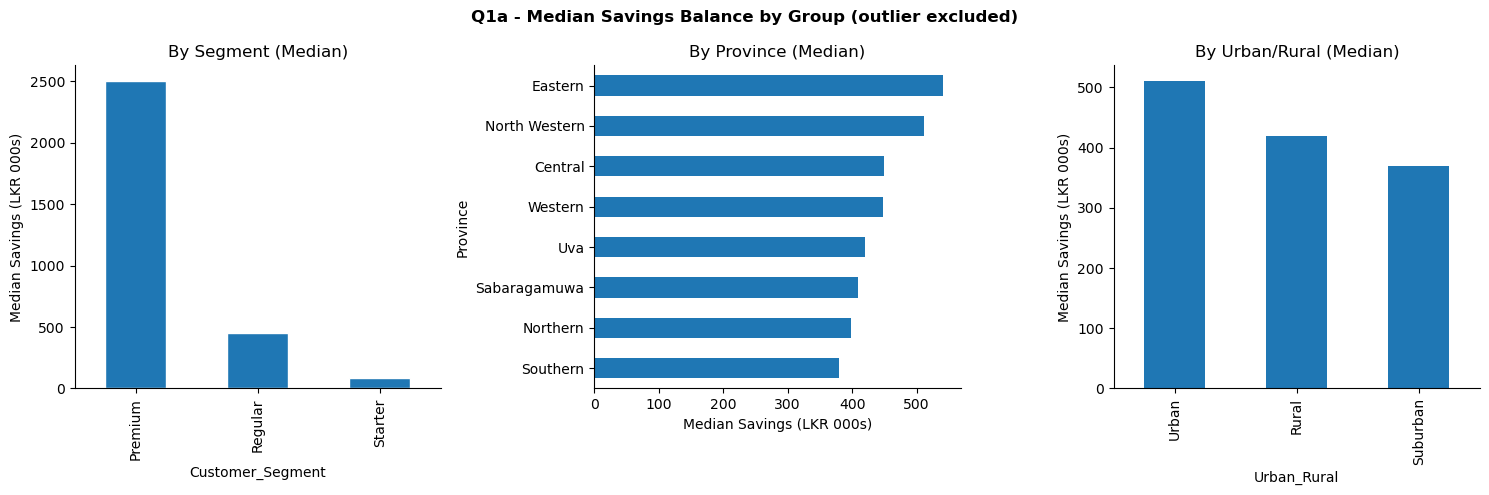

In [14]:
df_clean = df[df["Savings_Balance"] < 999_000_000]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Q1a - Median Savings Balance by Group (outlier excluded)', fontweight='bold')

df_clean.groupby('Customer_Segment')['Savings_Balance'].median().sort_values(ascending=False).div(1000).plot.bar(ax=axes[0], edgecolor='white')
axes[0].set(title='By Segment (Median)', ylabel='Median Savings (LKR 000s)')

df_clean.groupby('Province')['Savings_Balance'].median().sort_values().div(1000).plot.barh(ax=axes[1])
axes[1].set(title='By Province (Median)', xlabel='Median Savings (LKR 000s)')

df_clean.groupby('Urban_Rural')['Savings_Balance'].median().sort_values(ascending=False).div(1000).plot.bar(ax=axes[2])
axes[2].set(title='By Urban/Rural (Median)', ylabel='Median Savings (LKR 000s)')

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Q1b - Age Group Hwith the Highest Total Savings

Age_Band        Total          Mean    Median  Count
   18-24 4.844363e+07 712406.260000 360107.16     68
   25-34 1.264052e+08 826178.035163 477760.52    153
   35-44 1.168049e+08 794590.834898 461148.18    147
   45-54 9.195474e+07 701944.605992 448866.68    131
     65+ 6.400158e+04  64001.580000  64001.58      1


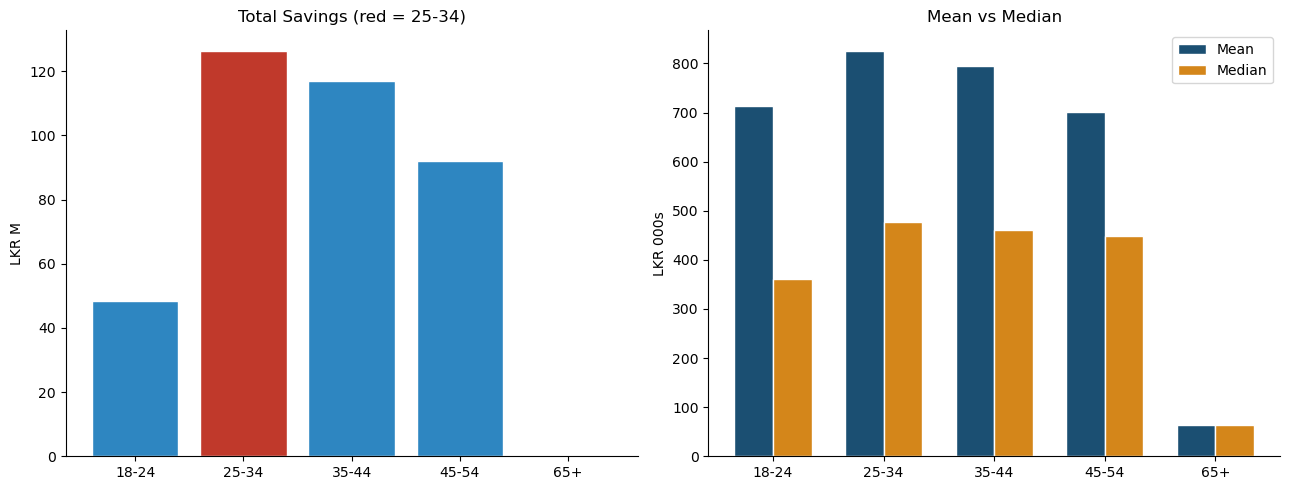

In [15]:
df_clean = df[df["Savings_Balance"] < 999_000_000]
age = df_clean.groupby("Age_Band", observed=True)["Savings_Balance"].agg(
    Total="sum", Mean="mean", Median="median", Count="count").reset_index()
age["Age_Band"] = age["Age_Band"].astype(str)
winner = age.loc[age["Total"].idxmax(), "Age_Band"]
print(age.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#C0392B" if b == winner else "#2E86C1" for b in age["Age_Band"]]

axes[0].bar(age["Age_Band"], age["Total"]/1e6, color=colors, edgecolor="white")
axes[0].set(title=f"Total Savings (red = {winner})", ylabel="LKR M")

x, w = np.arange(len(age)), 0.35
axes[1].bar(x-w/2, age["Mean"]/1e3,   w, color="#1B4F72", label="Mean",   edgecolor="white")
axes[1].bar(x+w/2, age["Median"]/1e3, w, color="#D4861A", label="Median", edgecolor="white")
axes[1].set_xticks(x); axes[1].set_xticklabels(age["Age_Band"])
axes[1].set(title="Mean vs Median", ylabel="LKR 000s"); axes[1].legend()

for ax in axes: ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Q1c - Growing vs Draining Savings

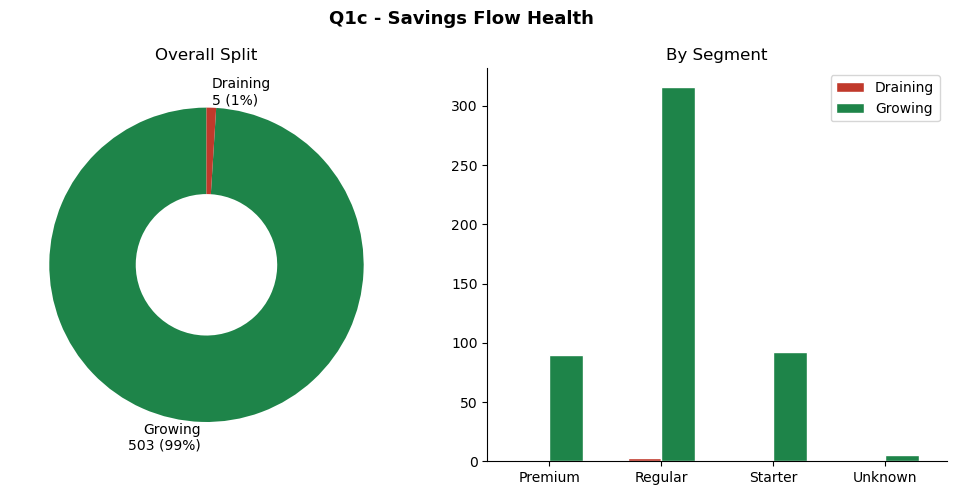

In [17]:
df['Flow_Cat'] = np.where(df['Net_Monthly_Flow'] > 0, 'Growing', 'Draining')

growing, draining, n = (df['Net_Monthly_Flow'] > 0).sum(), (df['Net_Monthly_Flow'] <= 0).sum(), len(df)
growers = df.loc[df['Flow_Cat'] == 'Growing', 'Net_Monthly_Flow']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Q1c - Savings Flow Health', fontsize=13, fontweight='bold')

axes[0].pie([growing, draining],
            labels=[f"Growing\n{growing} ({100*growing/n:.0f}%)", f"Draining\n{draining} ({100*draining/n:.0f}%)"],
            colors=['#1E8449', '#C0392B'], wedgeprops=dict(width=0.55), startangle=90)
axes[0].set_title('Overall Split')

(df.groupby(['Customer_Segment', 'Flow_Cat']).size().unstack(fill_value=0)
   .plot(kind='bar', ax=axes[1], color=['#C0392B', '#1E8449'], edgecolor='white', width=0.6))
axes[1].set(title='By Segment', xlabel='')
axes[1].tick_params(axis='x', rotation=0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend(title='')

plt.tight_layout()
plt.show()

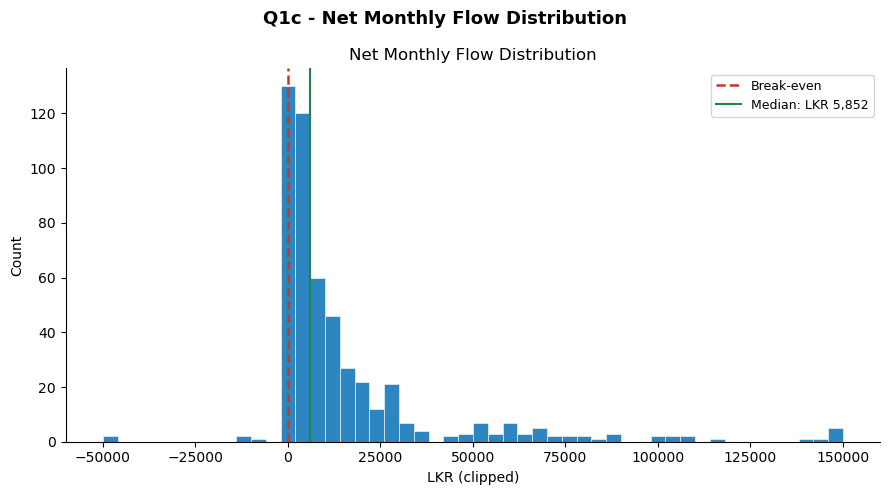

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Q1c - Net Monthly Flow Distribution', fontsize=13, fontweight='bold')

med = df['Net_Monthly_Flow'].median()
ax.hist(df['Net_Monthly_Flow'].clip(-50000, 150000), bins=50, color='#2E86C1', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='#C0392B', linestyle='--', linewidth=1.8, label='Break-even')
ax.axvline(med, color='#1E8449', linewidth=1.5, label=f"Median: LKR {med:,.0f}")
ax.set(title='Net Monthly Flow Distribution', xlabel='LKR (clipped)', ylabel='Count')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Q2a: Loan Penetration

Overall loan penetration: 43.1%

By Segment:
 Customer_Segment
Premium    45.1
Regular    44.2
Unknown    40.0
Starter    37.6
Name: Has_Loan, dtype: float64

By Channel:
 Acquisition_Channel
Agent       47.5
Referral    43.2
Branch      41.3
Digital     40.9
Name: Has_Loan, dtype: float64


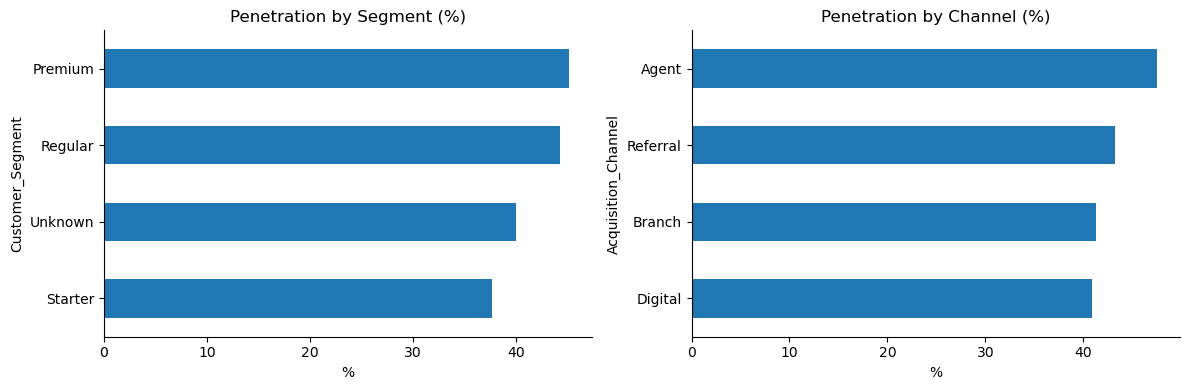

In [19]:
loan_df = df[df["Has_Loan"] == "Yes"]
overall = round(len(loan_df) / len(df) * 100, 1)
print(f"Overall loan penetration: {overall}%")

seg_pen = df.groupby("Customer_Segment")["Has_Loan"].apply(lambda x: round((x=="Yes").sum()/len(x)*100,1))
ch_pen  = df.groupby("Acquisition_Channel")["Has_Loan"].apply(lambda x: round((x=="Yes").sum()/len(x)*100,1))
print("\nBy Segment:\n", seg_pen.sort_values(ascending=False))
print("\nBy Channel:\n", ch_pen.sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
seg_pen.sort_values().plot.barh(ax=axes[0]); axes[0].set(title="Penetration by Segment (%)", xlabel="%")
ch_pen.sort_values().plot.barh(ax=axes[1]);  axes[1].set(title="Penetration by Channel (%)",  xlabel="%")
for ax in axes: ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Q2b: Debt-to-Savings Ratio

Borrowers with D:S > 1.0: 126 (58.6% of borrowers)
Total LKR exposure:       LKR 131,298,496

Avg D:S:   5.08
Median D:S: 1.66


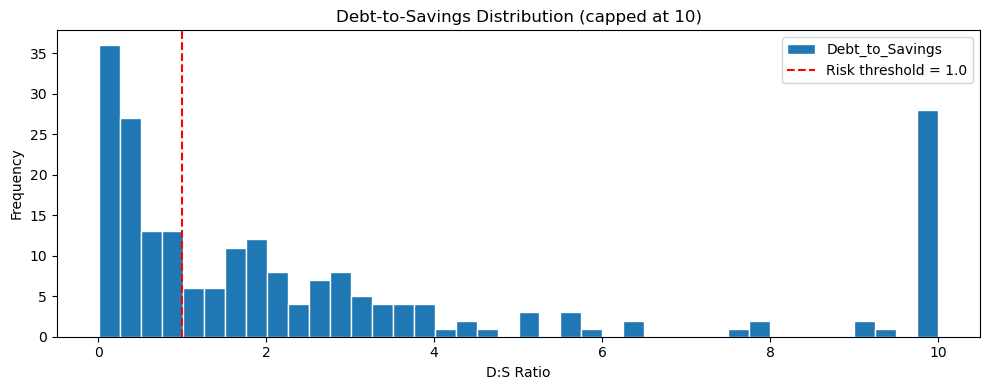

In [20]:
dts = loan_df[loan_df["Debt_to_Savings"].notna()].copy()
exceed = dts[dts["Debt_to_Savings"] > 1.0]
print(f"Borrowers with D:S > 1.0: {len(exceed)} ({round(len(exceed)/len(dts)*100,1)}% of borrowers)")
print(f"Total LKR exposure:       LKR {exceed['Outstanding_Loan_Balance'].sum():,.0f}")
print(f"\nAvg D:S:   {dts['Debt_to_Savings'].mean():.2f}")
print(f"Median D:S: {dts['Debt_to_Savings'].median():.2f}")

dts["Debt_to_Savings"].clip(0, 10).plot.hist(bins=40, figsize=(10, 4), edgecolor="white")
plt.axvline(1.0, color="red", linestyle="--", label="Risk threshold = 1.0")
plt.legend(); plt.title("Debt-to-Savings Distribution (capped at 10)")
plt.xlabel("D:S Ratio"); plt.tight_layout(); plt.show()

## Q2c: Default Patterns

Overall default rate: 10.1%  (target < 5%)

By Segment:
 Customer_Segment
Starter    17.1
Premium     9.8
Regular     8.6
Unknown     0.0
Name: Loan_Repayment_Status, dtype: float64

By Loan Type:
 Loan_Type
Vehicle     15.7
Housing     11.5
Personal     7.3
Business     6.8
Name: Loan_Repayment_Status, dtype: float64


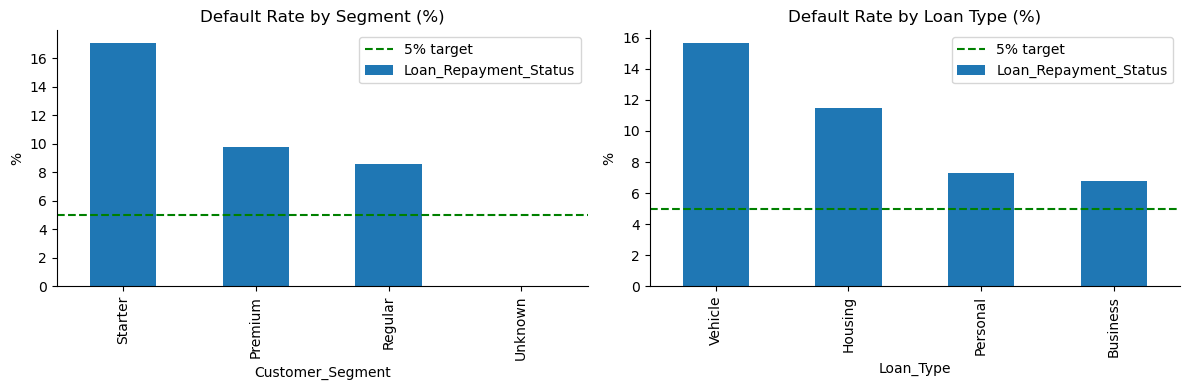

In [21]:
loan_valid = loan_df[loan_df["Loan_Repayment_Status"].notna()]
overall_def = round((loan_valid["Loan_Repayment_Status"]=="Defaulted").sum() / len(loan_valid) * 100, 1)
print(f"Overall default rate: {overall_def}%  (target < 5%)")

seg_def = loan_valid.groupby("Customer_Segment")["Loan_Repayment_Status"].apply(
    lambda x: round((x=="Defaulted").sum()/len(x)*100,1)).sort_values(ascending=False)
lt_def = loan_valid[loan_valid["Loan_Type"].notna()].groupby("Loan_Type")["Loan_Repayment_Status"].apply(
    lambda x: round((x=="Defaulted").sum()/len(x)*100,1)).sort_values(ascending=False)
print("\nBy Segment:\n", seg_def)
print("\nBy Loan Type:\n", lt_def)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
seg_def.plot.bar(ax=axes[0]); axes[0].axhline(5, color="green", linestyle="--", label="5% target"); axes[0].set(title="Default Rate by Segment (%)", ylabel="%"); axes[0].legend()
lt_def.plot.bar(ax=axes[1]);  axes[1].axhline(5, color="green", linestyle="--", label="5% target"); axes[1].set(title="Default Rate by Loan Type (%)",  ylabel="%"); axes[1].legend()
for ax in axes: ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

##  Q3a: App vs Non-App Savings

                     mean    median  count
Mobile_App_User                           
No               786483.0  444522.0    168
Yes              754912.0  448867.0    335

Mean uplift:   +-4.0%
Median diff:   LKR 4,345
Conclusion: Mean diverges but median is similar → selection bias likely, not causation.


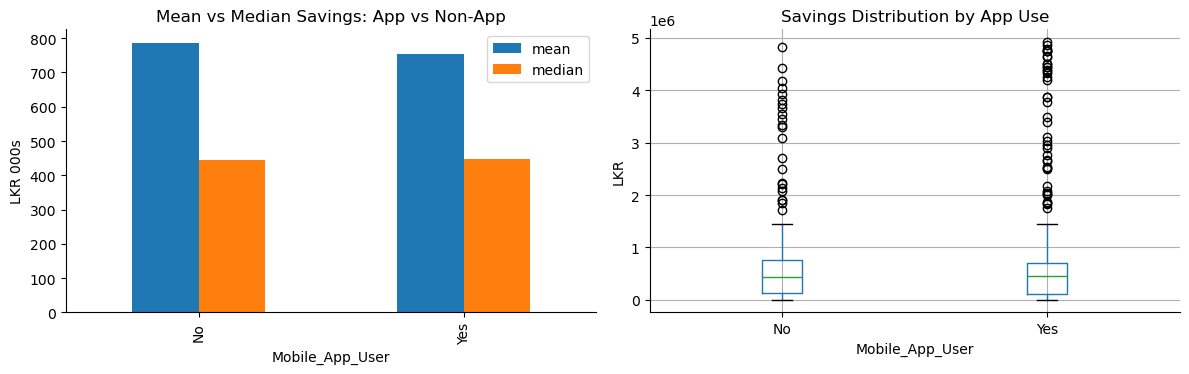

In [22]:
app = df.groupby("Mobile_App_User")["Savings_Balance"].agg(["mean","median","count"]).round(0)
print(app)

yes_mean = app.loc["Yes","mean"]; no_mean = app.loc["No","mean"]
yes_med  = app.loc["Yes","median"]; no_med  = app.loc["No","median"]
print(f"\nMean uplift:   +{round((yes_mean-no_mean)/no_mean*100,1)}%")
print(f"Median diff:   LKR {yes_med-no_med:,.0f}")
print("Conclusion: Mean diverges but median is similar → selection bias likely, not causation.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
app[["mean","median"]].div(1000).plot.bar(ax=axes[0])
axes[0].set(title="Mean vs Median Savings: App vs Non-App", ylabel="LKR 000s")

df.boxplot(column="Savings_Balance", by="Mobile_App_User", ax=axes[1])
axes[1].set(title="Savings Distribution by App Use", ylabel="LKR")
plt.suptitle("")
for ax in axes: ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Q3b: Cross-Sell Opportunity

Cross-sell candidates:  255 (50.2% of base)
Total savings held:     LKR 225,253,200
Avg savings held:       LKR 883,346

By Segment:
                  count          sum       mean
Customer_Segment                               
Premium              58  154757639.0  2668235.0
Regular             151   66455730.0   440104.0
Starter              46    4039831.0    87822.0


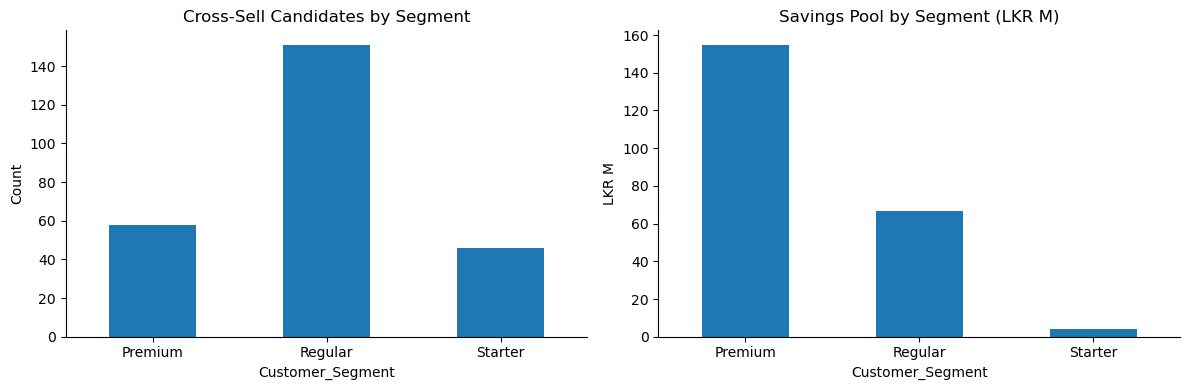

In [23]:
xsell = df[df["CrossSell_Opportunity"]]
print(f"Cross-sell candidates:  {len(xsell):,} ({round(len(xsell)/len(df)*100,1)}% of base)")
print(f"Total savings held:     LKR {xsell['Savings_Balance'].sum():,.0f}")
print(f"Avg savings held:       LKR {xsell['Savings_Balance'].mean():,.0f}")
print("\nBy Segment:")
print(xsell.groupby("Customer_Segment")["Savings_Balance"].agg(["count","sum","mean"]).round(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xsell.groupby("Customer_Segment").size().plot.bar(ax=axes[0])
axes[0].set(title="Cross-Sell Candidates by Segment", ylabel="Count")
xsell.groupby("Customer_Segment")["Savings_Balance"].sum().div(1e6).plot.bar(ax=axes[1])
axes[1].set(title="Savings Pool by Segment (LKR M)", ylabel="LKR M")
for ax in axes: ax.tick_params(axis="x", rotation=0); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Q3c: Channel Quality

                          Avg  Count  Default_%
Acquisition_Channel                            
Branch               836462.1    124       11.5
Digital              821605.4    131       11.1
Referral             753335.3    130       12.7
Agent                641858.4    118        5.4

Best risk-adjusted channel: Agent
Implication: Focus acquisition spend on this channel — it delivers higher-value, lower-risk customers.


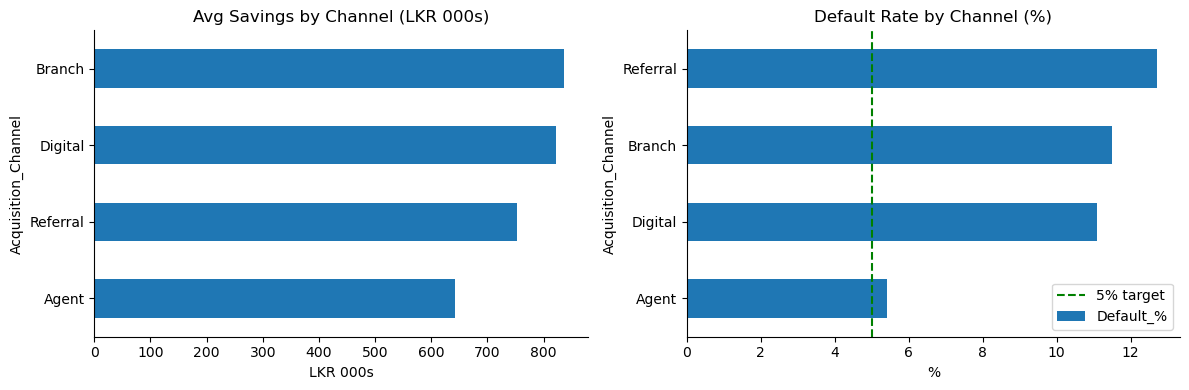

In [24]:
loan_valid = df[df["Has_Loan"]=="Yes"][df[df["Has_Loan"]=="Yes"]["Loan_Repayment_Status"].notna()]

ch_sav = df.groupby("Acquisition_Channel")["Savings_Balance"].agg(Avg="mean", Count="count")
ch_def = loan_valid.groupby("Acquisition_Channel")["Loan_Repayment_Status"].apply(
    lambda x: round((x=="Defaulted").sum()/len(x)*100,1)).rename("Default_%")
ch = ch_sav.join(ch_def).round(1)
print(ch.sort_values("Avg", ascending=False))
best = ch["Default_%"].idxmin()
print(f"\nBest risk-adjusted channel: {best}")
print("Implication: Focus acquisition spend on this channel — it delivers higher-value, lower-risk customers.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ch["Avg"].div(1000).sort_values().plot.barh(ax=axes[0])
axes[0].set(title="Avg Savings by Channel (LKR 000s)", xlabel="LKR 000s")
ch["Default_%"].sort_values().plot.barh(ax=axes[1])
axes[1].axvline(5, color="green", linestyle="--", label="5% target"); axes[1].legend()
axes[1].set(title="Default Rate by Channel (%)", xlabel="%")
for ax in axes: ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()